This project focuses on natural language processing (NLP) to analyze financial market sentiment from news headlines. By extracting relevant words and phrases from Yahoo finance, we assess the emotional tone and generate a sentiment score ranging from pessimistic to optimistic on a scale of 1 to 10. This quantifiable measure aids in understanding public sentiment effectively.


Utilizing Beautiful Soup, we perform web scraping to gather real-time data. The objective is to extract the latest 100 news headlines related to macroeconomics, stocks, bonds, currencies and commodities. This ensures that our analysis is based on up-to-date information, allowing us to capture current trends and sentiments that influence economic perceptions and discussions.


Incorporating the Natural Language Toolkit (NLTK), we employ various techniques such as tokenization, lemmatization, and filtering of stop words. This processing transforms raw text into meaningful numerical representations. By refining the language data, we enhance the accuracy of our sentiment analysis, making it more insightful and relevant to the topic at hand.


The final output includes a sentiment score that quantifies emotional tone on a scale of 1 to 10. Additionally, we create visualizations to illustrate the distribution of frequently occurring words. These charts provide a clear representation of prominent sentiments and themes, enabling deeper insights into macroeconomic discussions and public opinions.

In [8]:
import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import FreqDist
import matplotlib.pyplot as plt

In [9]:
# scrape Yahoo Finance news headlines
url = "https://finance.yahoo.com/topic/economic-news/"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# find all headline texts within the specific section
headlines = soup.select('section.yf-1ce4p3e div.topic-stream ul.yf-1drgw5l li a[href*="/news/"]')
headline_texts = [h.get_text().strip() for h in headlines]
headline_texts = list(set(headline_texts))  # Remove duplicates

In [10]:
# download and Initialize NLTK resources
# nltk.download('wordnet')
# nltk.download('stopwords')
tokenizer = RegexpTokenizer(r'\w+')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# sentiment dictionaries
bullish_words = {'strong', 'growth', 'surge', 'rally', 'optimistic', 'profit', 'gain', 'positive', 'bullish', 'rise', 'uptrend', 'robust', 'prosperity', 'advancement', 'momentum', 'expansion', 'confidence', 'victory', 'boom', 'thrive', 'ceasefire', 'cooperate', 'agree', 'confident'}
bearish_words = {'weak', 'decline', 'drop', 'risk', 'uncertainty', 'loss', 'negative', 'bearish', 'fall', 'recession', 'downturn', 'slump', 'deterioration', 'bear market', 'setback', 'pessimistic', 'crisis', 'stagnation', 'falter', 'plummet', 'war', 'argue', 'disagree', 'worry'}
sentiment_words = bullish_words | bearish_words

# calculate sentiment for each headline and average
total_score = 0
count = 0
all_words = []

In [11]:
# function for cleaning and tokenizing text
def process_text(text):
    tokens = tokenizer.tokenize(text.lower())
    return [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    
# function for scoring sentiment in 1-10 scale. 1=very bearish, 10=very bullish
def score_sentiment(text):
    tokens = process_text(text)
    bullish_count = sum(1 for w in tokens if w in bullish_words)
    bearish_count = sum(1 for w in tokens if w in bearish_words)
    total = bullish_count + bearish_count
    if total == 0:
        return 5  # Neutral if no sentiment words
    score = 5 + (bullish_count - bearish_count) * 2
    return max(1, min(10, round(score)))

In [12]:
for headline in headline_texts:
    try:
        score = score_sentiment(headline)
        total_score += score
        count += 1
        # print(f"Headline: {headline}, Sentiment Score: {score}")
        all_words.extend([w for w in process_text(headline) if w in sentiment_words])
    except Exception as e:
        print(f"Error processing headline: {e}")

In [13]:
# calculate average sentiment
average_score = total_score / count if count > 0 else 5
print(f"\nToday's Average Sentiment Score: {average_score:.2f} (1=Very Bearish, 10=Very Bullish)")


Today's Average Sentiment Score: 3.98 (1=Very Bearish, 10=Very Bullish)


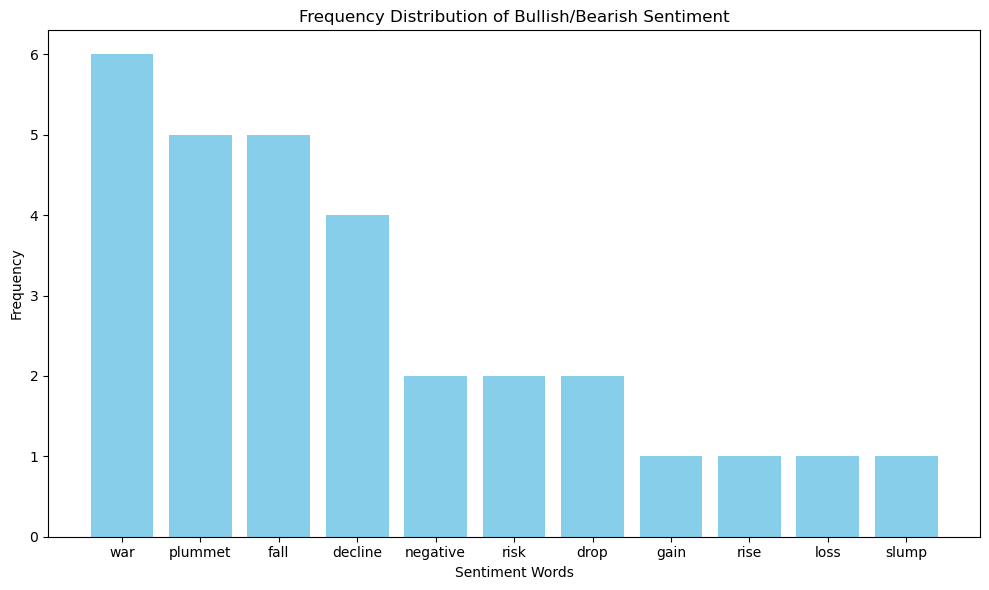

In [14]:
# generate frequency distribution and plot
if all_words:
    freq_dist = FreqDist(all_words)
    # Sort words by frequency (most frequent first)
    sorted_words = sorted(freq_dist.items(), key=lambda x: x[1], reverse=True)
    words, frequencies = zip(*sorted_words)
    
    # Plot cumulative frequency distribution
    plt.figure(figsize=(10, 6))
    plt.bar(words, frequencies, color='skyblue') 
    plt.xlabel('Sentiment Words')
    plt.ylabel('Frequency')
    plt.title('Frequency Distribution of Bullish/Bearish Sentiment')
    plt.tight_layout()
    plt.show()
else:
    print("No sentiment words found in headlines.")